# COMP34212 — Convolutional SNN for CIFAR-10 Classification
**Adapted from FovealVectorBrain (FYP DVS event-camera tracking CSNN)**




---

## This notebook has been adapted from my final year project for the cognitive robotics coursework

| Component | FYP (FovealVectorBrain) | This Notebook |
|---|---|---|
| Input channels | 2 (DVS ON/OFF polarity) | 3 (RGB) |
| Input size | 64×64 | 32×32 (CIFAR-10) |
| Input encoding | Pre-processed event frames | Rate / Latency encoder |
| Pool size | AdaptiveAvgPool(8,8) | AdaptiveAvgPool(4,4) |
| fc1 input | 32×8×8 = 2048 | 32×4×4 = 512 |
| Output head | Linear(128→2) velocity | Linear(128→10) classes |
| Readout | Mean velocity across T | Sum membrane across T + softmax |
| LIF neuron | Identical (β=0.9, fast_sigmoid) | Identical |
| Temporal loop | Identical | Identical |


## Cell 1 — Install Dependencies


In [1]:
!pip install torch torchvision snntorch matplotlib --quiet
print("✓ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.7 MB/s eta 0:00:00
✓ Dependencies installed


## Cell 2 — Imports and Config

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import snntorch as snn
from snntorch import surrogate
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Hyperparameters (edit these to run individual experiments) ───────────────
BATCH_SIZE  = 128
EPOCHS      = 20
NUM_CLASSES = 10

# Sweep axes — all combinations explored in Cell 6
TIMESTEPS      = [4, 8, 16, 32]
LEARNING_RATES = [1e-2, 1e-3, 1e-4]
ENCODINGS_LIST = ["rate", "latency"]

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("✓ Config ready")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
✓ Config ready


## Cell 3 — Load CIFAR-10
CIFAR-10 downloads automatically (~170MB). This only happens once — subsequent runs load from cache.

**Dataset facts:**
- 60,000 images total: 50,000 train / 10,000 test
- 10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck
- Image size: 32×32 RGB
- Normalisation values are the standard CIFAR-10 channel means and stds

100%|██████████| 170M/170M [00:04<00:00, 36.4MB/s]


Train samples: 50,000
Test  samples: 10,000
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Batch shape: torch.Size([128, 3, 32, 32])  (B, C, H, W)
Label shape: torch.Size([128])


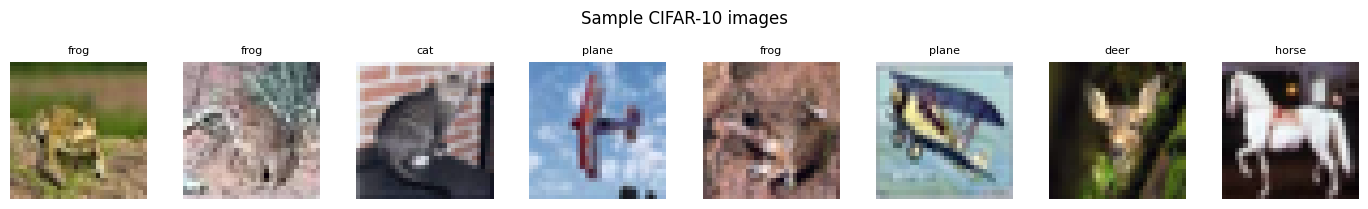

In [3]:
# Normalise to approximately [-1, 1] using CIFAR-10 dataset statistics
# the standard values used across the literature
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),   # per-channel means
        std =(0.2023, 0.1994, 0.2010),   # per-channel stds
    ),
])

# Download=True fetches the data automatically
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

print(f"Train samples: {len(train_dataset):,}")
print(f"Test  samples: {len(test_dataset):,}")
print(f"Classes: {CLASSES}")

# Preview a batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}  (B, C, H, W)")
print(f"Label shape: {labels.shape}")

# Show sample images
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    img = images[i].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img); ax.axis('off')
    ax.set_title(CLASSES[labels[i]], fontsize=8)
plt.suptitle("Sample CIFAR-10 images", y=1.02)
plt.tight_layout(); plt.show()

## Cell 4 — Input Encoders

Static CIFAR-10 images must be converted into **spike trains** before being fed into the SNN.
Two encoding strategies are implemented and compared as a hyperparameter axis:

### Rate Coding
Pixel intensity → spike **probability** per timestep.  
A bright pixel (intensity ≈ 1) fires a spike on most timesteps.  
A dark pixel (intensity ≈ 0) rarely fires.  
Each timestep is an independent Bernoulli sample.

### Latency Coding
Pixel intensity → spike **timing** (one spike per pixel total).  
A bright pixel fires **early** (low timestep index).  
A dark pixel fires **late** (high timestep index).  
More information-efficient — one spike carries the full signal — but more sensitive to T.

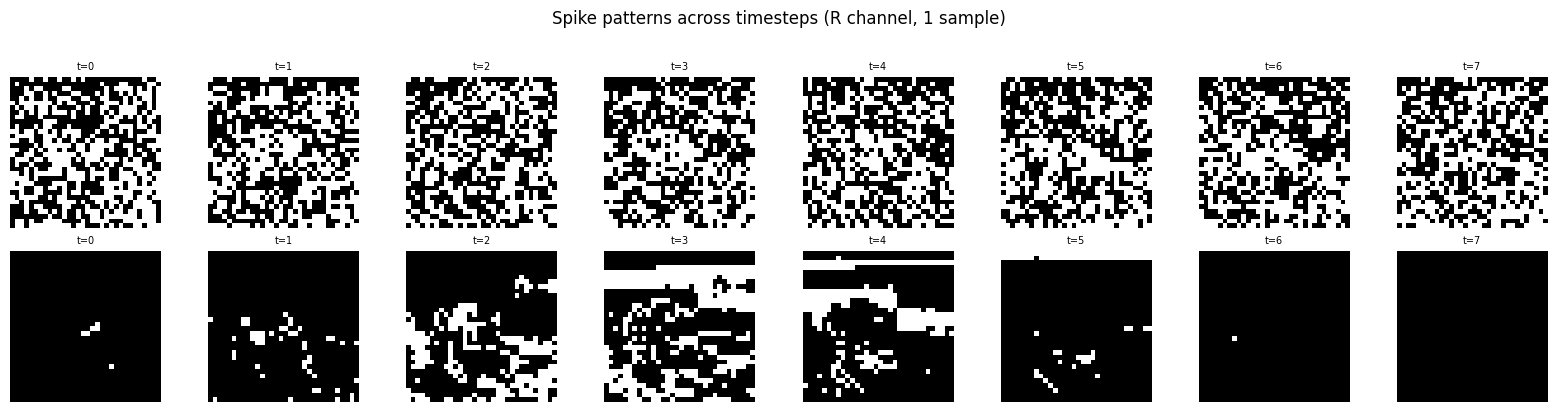

Rate encoding    — mean spike rate: 0.406  spikes/pixel/timestep
Latency encoding — mean spike rate: 0.125 spikes/pixel/timestep


In [4]:
def rate_encode(x: torch.Tensor, T: int) -> torch.Tensor:
    """
    Rate coding: pixel intensity → Bernoulli spike probability per timestep.
    Input:  x  [B, C, H, W]  normalised CIFAR-10 image
    Output:    [B, T, C, H, W]  binary spike tensor
    """
    # Rescale from ~[-1,1] to [0,1] for use as probability
    x_prob = (x - x.min()) / (x.max() - x.min() + 1e-8)
    # Independently sampled a spike at each timestep
    spikes = torch.stack(
        [torch.bernoulli(x_prob) for _ in range(T)], dim=1
    )  # [B, T, C, H, W]
    return spikes.to(x.device)


def latency_encode(x: torch.Tensor, T: int) -> torch.Tensor:
    """
    Latency coding: brighter pixels fire earlier, darker pixels fire later.
    Exactly one spike per pixel across all T timesteps.
    Input:  x  [B, C, H, W]
    Output:    [B, T, C, H, W]  binary spike tensor
    """
    x_prob = (x - x.min()) / (x.max() - x.min() + 1e-8)
    B, C, H, W = x_prob.shape
    # Bright pixel (≈1) → fire at t=0; dark pixel (≈0) → fire at t=T-1
    fire_t = ((1.0 - x_prob) * (T - 1)).long().clamp(0, T - 1)
    spikes = torch.zeros(B, T, C, H, W, device=x.device)
    spikes.scatter_(1, fire_t.unsqueeze(1), 1.0)
    return spikes


ENCODINGS = {"rate": rate_encode, "latency": latency_encode}

# ── Visualise the encodings on one sample image ──────────────────────────────
sample_img = images[0:1]   # [1, 3, 32, 32]
T_demo = 8

rate_spikes    = rate_encode(sample_img, T_demo)     # [1, 8, 3, 32, 32]
latency_spikes = latency_encode(sample_img, T_demo)

fig, axes = plt.subplots(2, T_demo, figsize=(16, 4))
for t in range(T_demo):
    # Show first channel (R) spike map at each timestep
    axes[0, t].imshow(rate_spikes[0, t, 0].numpy(), cmap='binary_r', vmin=0, vmax=1)
    axes[0, t].set_title(f"t={t}", fontsize=7); axes[0, t].axis('off')
    axes[1, t].imshow(latency_spikes[0, t, 0].numpy(), cmap='binary_r', vmin=0, vmax=1)
    axes[1, t].set_title(f"t={t}", fontsize=7); axes[1, t].axis('off')

axes[0, 0].set_ylabel("Rate", fontsize=9)
axes[1, 0].set_ylabel("Latency", fontsize=9)
plt.suptitle("Spike patterns across timesteps (R channel, 1 sample)", y=1.02)
plt.tight_layout(); plt.show()

print(f"Rate encoding    — mean spike rate: {rate_spikes.mean():.3f}  spikes/pixel/timestep")
print(f"Latency encoding — mean spike rate: {latency_spikes.mean():.3f} spikes/pixel/timestep")

## Cell 5 — CSNN Model

### Architecture
Adapted from `FovealVectorBrain` (FYP DVS tracking SNN). The convolutional backbone and LIF neuron configuration are transferred directly; only the input channels, pool size, and output head change.

```
Input [B, T, 3, 32, 32]  ← rate/latency encoded CIFAR-10
  ↓  (loop over t=0..T-1)
Conv2d(3→16, 5×5, stride=2) → LIF(β=0.9)   output: [B, 16, 15, 15]
Conv2d(16→32, 5×5, stride=2) → LIF(β=0.9)  output: [B, 32,  6,  6]
AdaptiveAvgPool2d(4×4) → Flatten            output: [B, 512]
Linear(512→128) → LIF(β=0.9)               output: [B, 128]
Linear(128→10)  [no LIF — membrane readout] output: [B, 10]
  ↓  (sum across T)
Logits [B, 10]  → CrossEntropyLoss
```

**Readout strategy:** Rather than taking the final spike output, we accumulate the membrane potential of the last linear layer across all T timesteps. This is the standard SNN classification readout — it provides a smoother, more stable signal than counting spikes from a single timestep.

In [5]:
class CIFAR_CSNN(nn.Module):
    """
    Convolutional SNN for CIFAR-10 classification.
    Adapted from FovealVectorBrain (FYP DVS tracking CSNN).
    """

    def __init__(self, beta: float = 0.9):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid()  # identical to FYP

        # ── The Retina: spatial feature extractors ──────────────────────────
        # FYP had in_channels=2 (DVS polarity). Changed to 3 for RGB.
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=1)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=1)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # ── Pooling: FYP used (8,8) for 64x64 input. Changed to (4,4) for 32x32.
        self.pool    = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten = nn.Flatten()

        # ── The Visual Cortex: dense integration ────────────────────────────
        # FYP: Linear(2048→128). Changed to Linear(512→128) for smaller input.
        self.fc1  = nn.Linear(32 * 4 * 4, 128)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # ── Classification readout (no LIF — continuous membrane accumulation)
        # FYP: Linear(128→2) for [vx, vy]. Changed to Linear(128→10) for CIFAR-10.
        self.fc_out = nn.Linear(128, NUM_CLASSES)

    def forward(self, x: torch.Tensor):
        """
        x: [B, T, C, H, W]  spike-encoded input
        returns: [B, 10]    class logits (membrane potential summed over T)
        """
        # Initialise membrane potentials — identical pattern to FYP
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        mem_out_sum = torch.zeros(x.size(0), NUM_CLASSES, device=x.device)

        for t in range(x.size(1)):
            frame = x[:, t]                      # [B, C, H, W]

            cur1       = self.conv1(frame)
            spk1, mem1 = self.lif1(cur1, mem1)   # spk1: binary spikes

            cur2       = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            pooled = self.pool(spk2)
            flat   = self.flatten(pooled)

            cur3       = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)

            # Accumulate output membrane across timesteps (classification readout)
            mem_out_sum += self.fc_out(spk3)

        return mem_out_sum   # raw logits — CrossEntropyLoss applies softmax internally


# ── Sanity check: forward pass with dummy data ───────────────────────────────
T_test = 8
dummy  = torch.bernoulli(torch.rand(4, T_test, 3, 32, 32))  # [B, T, C, H, W]
model  = CIFAR_CSNN(beta=0.9)
out    = model(dummy)

print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}   ← should be [4, 10]")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print("✓ Model architecture OK")

Input shape:  torch.Size([4, 8, 3, 32, 32])
Output shape: torch.Size([4, 10])   ← should be [4, 10]
Total parameters: 81,002
✓ Model architecture OK


## Cell 6 — Training and Evaluation Functions

In [6]:
def train_one_epoch(model, loader, optimizer, encoder, T, device):
    model.train()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Convert static images → spike trains
        spikes = encoder(images, T)       # [B, T, C, H, W]

        optimizer.zero_grad()
        logits = model(spikes)            # [B, 10]
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, encoder, T, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            spikes = encoder(images, T)
            logits = model(spikes)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total

print("✓ Training and evaluation functions ready")

✓ Training and evaluation functions ready


## Cell 7 — Hyperparameter Sweep

We vary **one axis at a time**, holding the other two fixed:

| Experiment | Varies | Fixed |
|---|---|---|
| Timesteps | T ∈ {4, 8, 16, 32} | LR=1e-3, Rate encoding |
| Learning rate | LR ∈ {1e-2, 1e-3, 1e-4} | T=16, Rate encoding |
| Input encoding | Rate vs Latency | T=16, LR=1e-3 |

Total: **7 configurations × 20 epochs**

⏱️ **Estimated runtime:**
- Colab GPU (T4): ~25–40 minutes total
- Local CPU: ~3–5 hours (not recommended for full sweep)



Configurations to run: 7
  1. T= 4  lr=1e-03  encoding=rate
  2. T= 8  lr=1e-03  encoding=rate
  3. T=16  lr=1e-03  encoding=rate
  4. T=32  lr=1e-03  encoding=rate
  5. T=16  lr=1e-02  encoding=rate
  6. T=16  lr=1e-04  encoding=rate
  7. T=16  lr=1e-03  encoding=latency

  [1/7] T4_lr1e-03_rate
  Epoch  1/20 | loss=1.9221 | train=29.1% | test=39.5%
  Epoch  2/20 | loss=1.6000 | train=41.5% | test=42.9%
  Epoch  3/20 | loss=1.4995 | train=45.5% | test=46.5%
  Epoch  4/20 | loss=1.4475 | train=47.3% | test=47.8%
  Epoch  5/20 | loss=1.4014 | train=49.3% | test=50.1%
  Epoch  6/20 | loss=1.3578 | train=50.8% | test=50.6%
  Epoch  7/20 | loss=1.3263 | train=52.0% | test=52.0%
  Epoch  8/20 | loss=1.2958 | train=53.2% | test=52.9%
  Epoch  9/20 | loss=1.2729 | train=54.2% | test=53.7%
  Epoch 10/20 | loss=1.2473 | train=55.2% | test=53.8%
  Epoch 11/20 | loss=1.2233 | train=56.2% | test=55.0%
  Epoch 12/20 | loss=1.2072 | train=56.7% | test=54.5%
  Epoch 13/20 | loss=1.1871 | train=57.5% 

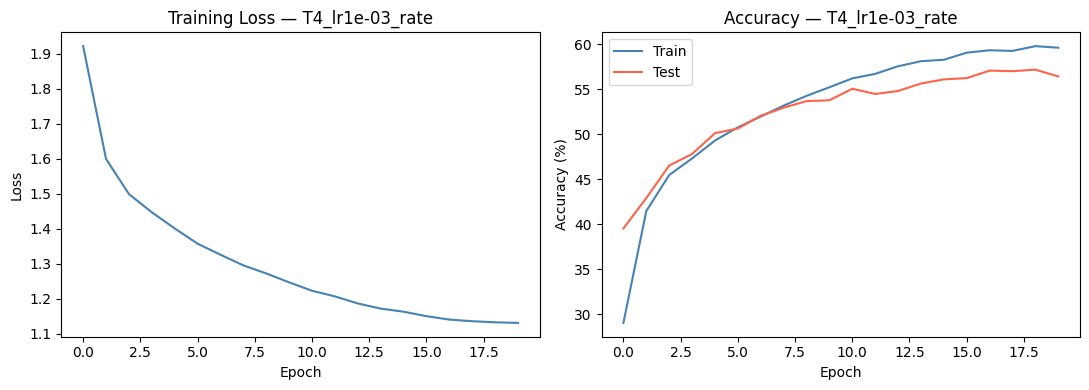


  [2/7] T8_lr1e-03_rate
  Epoch  1/20 | loss=1.8021 | train=33.7% | test=42.6%
  Epoch  2/20 | loss=1.5047 | train=45.3% | test=47.8%
  Epoch  3/20 | loss=1.4191 | train=48.9% | test=49.6%
  Epoch  4/20 | loss=1.3625 | train=50.8% | test=52.0%
  Epoch  5/20 | loss=1.3193 | train=52.5% | test=52.5%
  Epoch  6/20 | loss=1.2756 | train=54.3% | test=54.1%
  Epoch  7/20 | loss=1.2415 | train=55.3% | test=54.7%
  Epoch  8/20 | loss=1.2138 | train=56.4% | test=55.6%
  Epoch  9/20 | loss=1.1789 | train=58.1% | test=56.5%
  Epoch 10/20 | loss=1.1528 | train=58.8% | test=56.5%
  Epoch 11/20 | loss=1.1279 | train=59.9% | test=58.2%
  Epoch 12/20 | loss=1.1007 | train=60.8% | test=58.0%
  Epoch 13/20 | loss=1.0790 | train=61.6% | test=58.6%
  Epoch 14/20 | loss=1.0618 | train=62.3% | test=58.4%
  Epoch 15/20 | loss=1.0411 | train=63.3% | test=59.1%
  Epoch 16/20 | loss=1.0312 | train=63.2% | test=59.2%
  Epoch 17/20 | loss=1.0189 | train=64.2% | test=60.0%
  Epoch 18/20 | loss=1.0111 | train=64.3

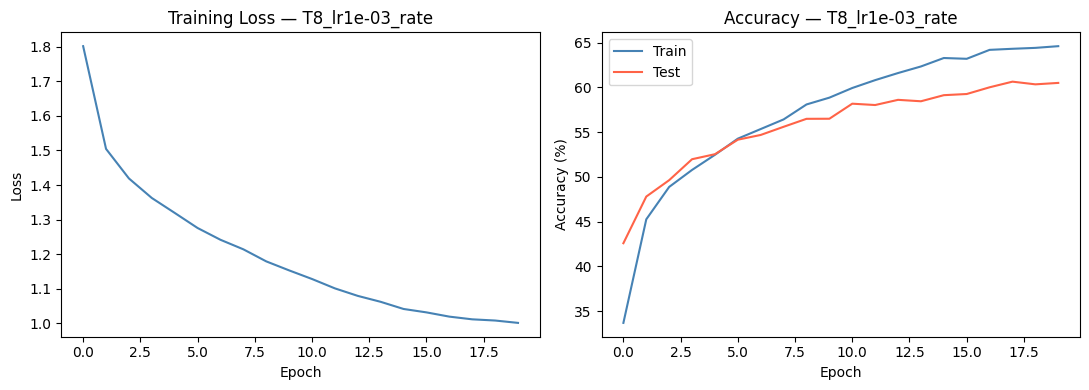


  [3/7] T16_lr1e-03_rate
  Epoch  1/20 | loss=1.7680 | train=35.9% | test=45.8%
  Epoch  2/20 | loss=1.4478 | train=47.8% | test=49.6%
  Epoch  3/20 | loss=1.3469 | train=51.6% | test=52.7%
  Epoch  4/20 | loss=1.2773 | train=54.3% | test=54.4%
  Epoch  5/20 | loss=1.2236 | train=56.2% | test=55.7%
  Epoch  6/20 | loss=1.1778 | train=57.9% | test=57.6%
  Epoch  7/20 | loss=1.1338 | train=59.8% | test=58.7%
  Epoch  8/20 | loss=1.0953 | train=60.9% | test=59.1%
  Epoch  9/20 | loss=1.0600 | train=62.4% | test=59.6%
  Epoch 10/20 | loss=1.0316 | train=63.5% | test=59.9%
  Epoch 11/20 | loss=0.9978 | train=64.7% | test=60.3%
  Epoch 12/20 | loss=0.9726 | train=65.5% | test=61.3%
  Epoch 13/20 | loss=0.9488 | train=66.6% | test=61.3%
  Epoch 14/20 | loss=0.9269 | train=67.4% | test=61.9%
  Epoch 15/20 | loss=0.9095 | train=68.0% | test=62.4%
  Epoch 16/20 | loss=0.8918 | train=68.5% | test=62.2%
  Epoch 17/20 | loss=0.8807 | train=69.0% | test=62.9%
  Epoch 18/20 | loss=0.8710 | train=69.

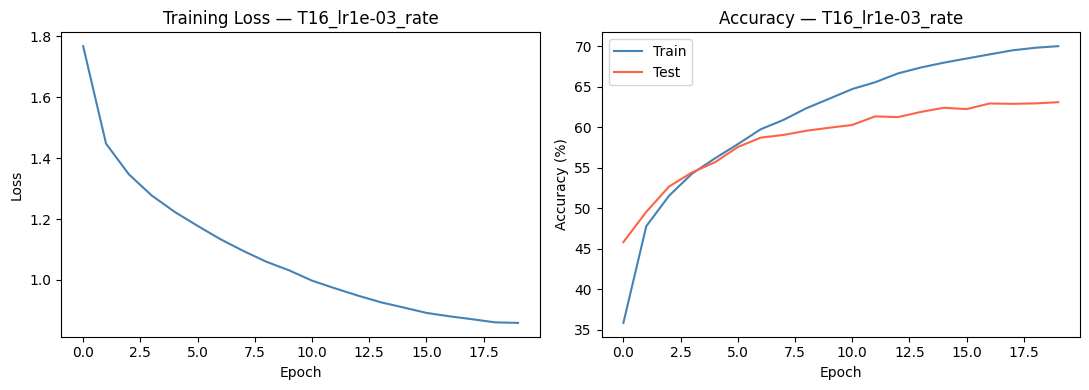


  [4/7] T32_lr1e-03_rate
  Epoch  1/20 | loss=1.8362 | train=33.4% | test=42.0%
  Epoch  2/20 | loss=1.5001 | train=45.6% | test=48.0%
  Epoch  3/20 | loss=1.3926 | train=49.6% | test=51.8%
  Epoch  4/20 | loss=1.3197 | train=52.7% | test=53.0%
  Epoch  5/20 | loss=1.2635 | train=54.6% | test=55.5%
  Epoch  6/20 | loss=1.2104 | train=56.5% | test=55.8%
  Epoch  7/20 | loss=1.1663 | train=58.1% | test=56.8%
  Epoch  8/20 | loss=1.1246 | train=59.9% | test=58.3%
  Epoch  9/20 | loss=1.0880 | train=61.2% | test=58.5%
  Epoch 10/20 | loss=1.0535 | train=62.6% | test=60.0%
  Epoch 11/20 | loss=1.0269 | train=63.5% | test=60.3%
  Epoch 12/20 | loss=0.9966 | train=64.6% | test=60.6%
  Epoch 13/20 | loss=0.9725 | train=65.5% | test=61.3%
  Epoch 14/20 | loss=0.9544 | train=66.2% | test=61.3%
  Epoch 15/20 | loss=0.9298 | train=67.2% | test=61.3%
  Epoch 16/20 | loss=0.9140 | train=67.5% | test=62.4%
  Epoch 17/20 | loss=0.9020 | train=68.0% | test=61.9%
  Epoch 18/20 | loss=0.8917 | train=68.

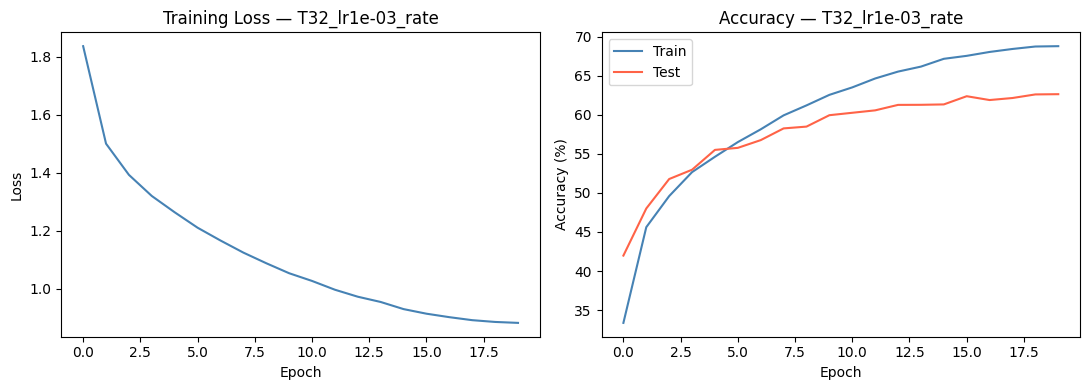


  [5/7] T16_lr1e-02_rate
  Epoch  1/20 | loss=2.3194 | train=10.0% | test=10.0%
  Epoch  2/20 | loss=2.3121 | train=10.0% | test=10.0%
  Epoch  3/20 | loss=2.3123 | train=9.9% | test=10.0%
  Epoch  4/20 | loss=2.3121 | train=9.9% | test=10.0%
  Epoch  5/20 | loss=2.3118 | train=9.7% | test=10.0%
  Epoch  6/20 | loss=2.3104 | train=10.1% | test=10.0%
  Epoch  7/20 | loss=2.3091 | train=10.0% | test=10.0%
  Epoch  8/20 | loss=2.3086 | train=9.9% | test=10.0%
  Epoch  9/20 | loss=2.3097 | train=9.9% | test=10.0%
  Epoch 10/20 | loss=2.3079 | train=9.8% | test=10.0%
  Epoch 11/20 | loss=2.3073 | train=9.8% | test=10.0%
  Epoch 12/20 | loss=2.3072 | train=9.9% | test=10.0%
  Epoch 13/20 | loss=2.3642 | train=9.9% | test=10.0%
  Epoch 14/20 | loss=2.2912 | train=11.4% | test=19.8%
  Epoch 15/20 | loss=1.9571 | train=27.8% | test=33.2%
  Epoch 16/20 | loss=1.7203 | train=37.0% | test=39.6%
  Epoch 17/20 | loss=1.6085 | train=41.1% | test=41.7%
  Epoch 18/20 | loss=1.5622 | train=42.8% | test

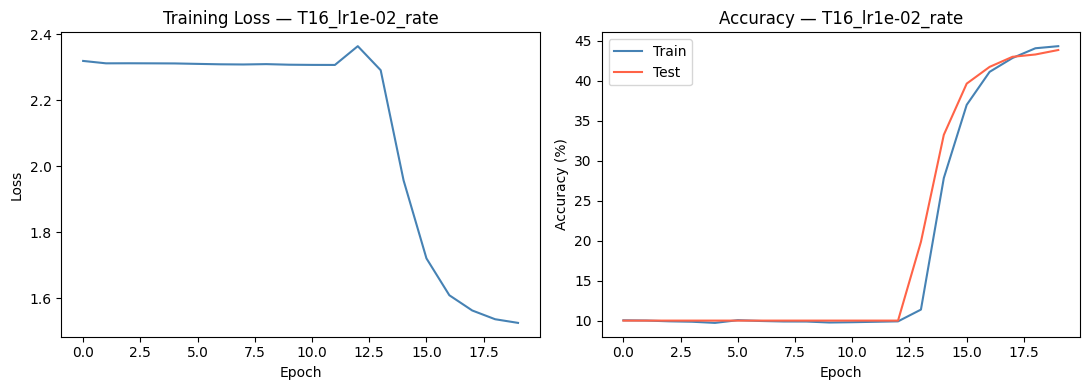


  [6/7] T16_lr1e-04_rate
  Epoch  1/20 | loss=2.0897 | train=23.5% | test=31.2%
  Epoch  2/20 | loss=1.8081 | train=35.2% | test=38.5%
  Epoch  3/20 | loss=1.6717 | train=40.1% | test=42.0%
  Epoch  4/20 | loss=1.5828 | train=43.3% | test=44.4%
  Epoch  5/20 | loss=1.5379 | train=45.2% | test=45.5%
  Epoch  6/20 | loss=1.5025 | train=46.1% | test=47.4%
  Epoch  7/20 | loss=1.4756 | train=47.0% | test=47.2%
  Epoch  8/20 | loss=1.4566 | train=47.5% | test=48.2%
  Epoch  9/20 | loss=1.4369 | train=48.3% | test=49.0%
  Epoch 10/20 | loss=1.4242 | train=48.7% | test=49.3%
  Epoch 11/20 | loss=1.4120 | train=49.4% | test=49.9%
  Epoch 12/20 | loss=1.4001 | train=49.8% | test=50.0%
  Epoch 13/20 | loss=1.3908 | train=50.2% | test=49.9%
  Epoch 14/20 | loss=1.3808 | train=50.5% | test=50.3%
  Epoch 15/20 | loss=1.3765 | train=50.6% | test=50.2%
  Epoch 16/20 | loss=1.3697 | train=51.1% | test=50.9%
  Epoch 17/20 | loss=1.3638 | train=51.3% | test=50.8%
  Epoch 18/20 | loss=1.3630 | train=51.

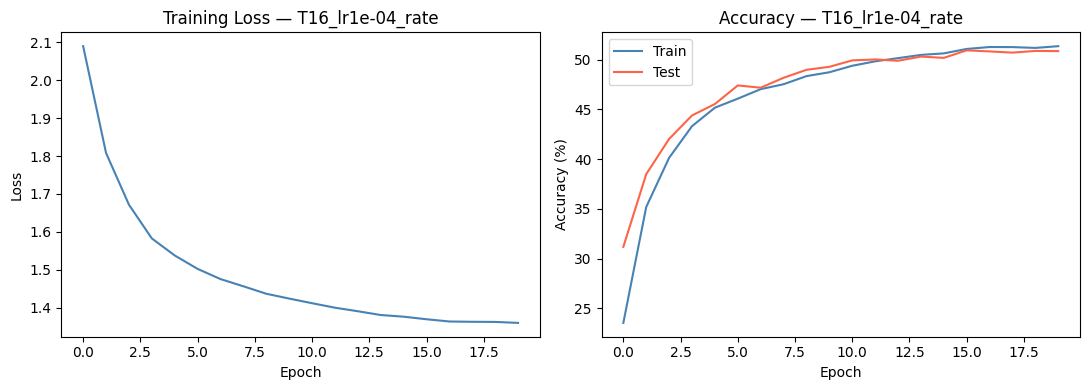


  [7/7] T16_lr1e-03_latency
  Epoch  1/20 | loss=1.8120 | train=33.4% | test=45.8%
  Epoch  2/20 | loss=1.4490 | train=47.7% | test=50.3%
  Epoch  3/20 | loss=1.3366 | train=52.0% | test=51.9%
  Epoch  4/20 | loss=1.2571 | train=54.9% | test=56.6%
  Epoch  5/20 | loss=1.1928 | train=57.4% | test=57.7%
  Epoch  6/20 | loss=1.1349 | train=59.8% | test=58.0%
  Epoch  7/20 | loss=1.0890 | train=61.5% | test=59.8%
  Epoch  8/20 | loss=1.0503 | train=62.6% | test=59.8%
  Epoch  9/20 | loss=1.0149 | train=64.0% | test=62.4%
  Epoch 10/20 | loss=0.9886 | train=65.0% | test=61.6%
  Epoch 11/20 | loss=0.9571 | train=66.2% | test=63.1%
  Epoch 12/20 | loss=0.9375 | train=66.7% | test=63.9%
  Epoch 13/20 | loss=0.9118 | train=67.9% | test=64.2%
  Epoch 14/20 | loss=0.8908 | train=68.4% | test=64.8%
  Epoch 15/20 | loss=0.8779 | train=69.0% | test=64.8%
  Epoch 16/20 | loss=0.8626 | train=69.7% | test=65.1%
  Epoch 17/20 | loss=0.8523 | train=70.1% | test=65.8%
  Epoch 18/20 | loss=0.8412 | train=

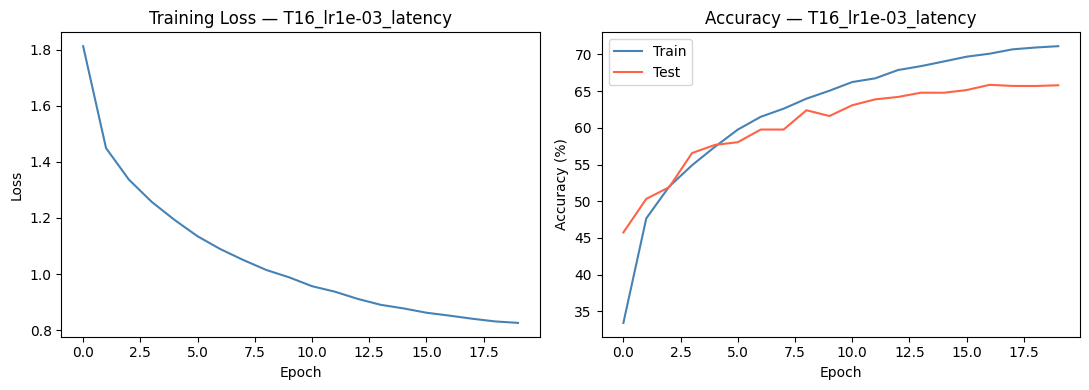


✓ Sweep complete


In [7]:
# ── Define sweep configurations ──────────────────────────────────────────────
SWEEP_CONFIGS = (
    [(T, 1e-3, "rate")     for T in TIMESTEPS] +       # vary T
    [(16, lr,  "rate")     for lr in LEARNING_RATES    # vary LR
                           if lr != 1e-3] +
    [(16, 1e-3, "latency")]                             # vary encoding
)
# Deduplicate
seen = set()
SWEEP_CONFIGS = [c for c in SWEEP_CONFIGS if not (c in seen or seen.add(c))]

print(f"Configurations to run: {len(SWEEP_CONFIGS)}")
for i, (T, lr, enc) in enumerate(SWEEP_CONFIGS):
    print(f"  {i+1}. T={T:2d}  lr={lr:.0e}  encoding={enc}")

# ── Run sweep ────────────────────────────────────────────────────────────────
results = []

for run_idx, (T, lr, enc_name) in enumerate(SWEEP_CONFIGS):
    tag = f"T{T}_lr{lr:.0e}_{enc_name}"
    print(f"\n{'='*55}")
    print(f"  [{run_idx+1}/{len(SWEEP_CONFIGS)}] {tag}")
    print(f"{'='*55}")

    encoder   = ENCODINGS[enc_name]
    model     = CIFAR_CSNN(beta=0.9).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, encoder, T, DEVICE)
        te_acc = evaluate(model, test_loader, encoder, T, DEVICE)
        scheduler.step()

        train_losses.append(tr_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)

        print(f"  Epoch {epoch:2d}/{EPOCHS} | "
              f"loss={tr_loss:.4f} | "
              f"train={tr_acc*100:.1f}% | "
              f"test={te_acc*100:.1f}%")

    best = max(test_accs)
    results.append({
        "T": T, "lr": lr, "encoding": enc_name,
        "best_test_acc": best,
        "train_losses":  train_losses,
        "train_accs":    train_accs,
        "test_accs":     test_accs,
        "tag": tag,
    })
    print(f"  ✓ Best test accuracy: {best*100:.2f}%")

    # Save per-config curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(train_losses, color='steelblue')
    ax1.set_title(f"Training Loss — {tag}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax2.plot([a*100 for a in train_accs], label="Train", color='steelblue')
    ax2.plot([a*100 for a in test_accs],  label="Test",  color='tomato')
    ax2.set_title(f"Accuracy — {tag}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/curve_{tag}.png", dpi=150)
    plt.show()

print("\n✓ Sweep complete")

## Cell 8 — Summary Plots

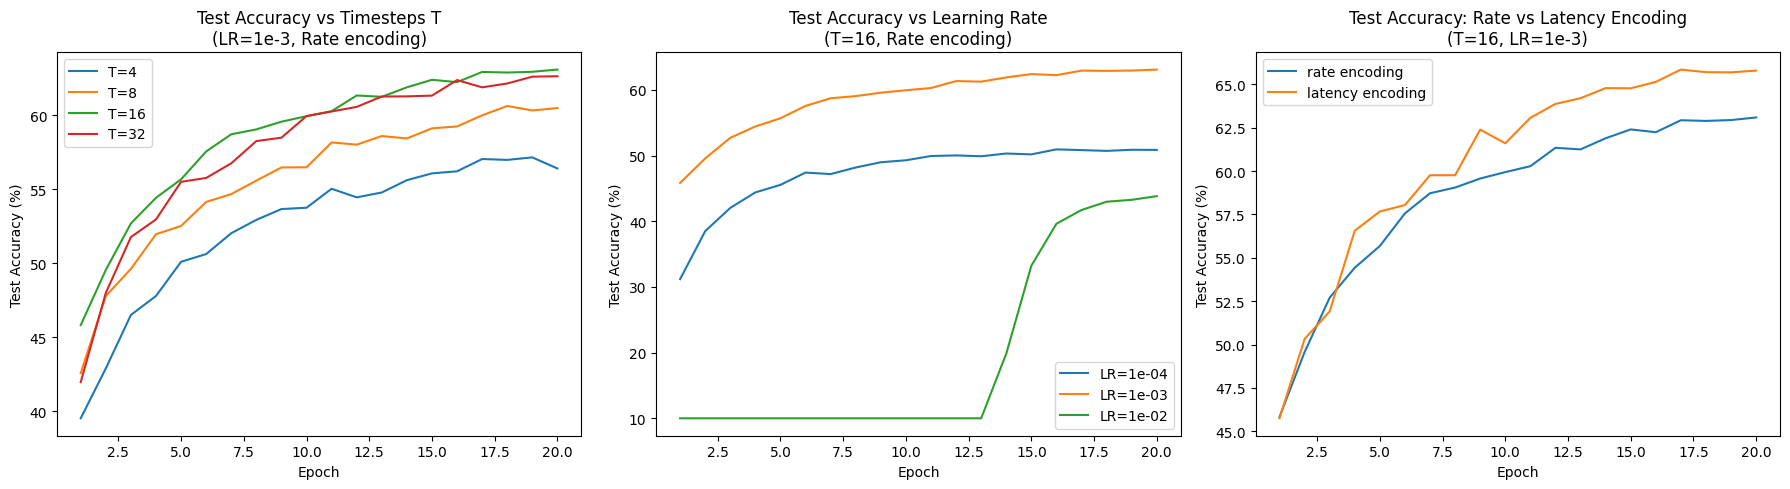

Saved: results/summary_plots.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Accuracy vs T ────────────────────────────────────────────────────
ax = axes[0]
t_res = sorted([r for r in results
                if r["lr"]==1e-3 and r["encoding"]=="rate"],
               key=lambda r: r["T"])
for r in t_res:
    ax.plot(range(1, EPOCHS+1), [a*100 for a in r["test_accs"]],
            label=f"T={r['T']}")
ax.set_title("Test Accuracy vs Timesteps T\n(LR=1e-3, Rate encoding)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Test Accuracy (%)")
ax.legend()

# ── Plot 2: Accuracy vs LR ───────────────────────────────────────────────────
ax = axes[1]
lr_res = sorted([r for r in results
                 if r["T"]==16 and r["encoding"]=="rate"],
                key=lambda r: r["lr"])
for r in lr_res:
    ax.plot(range(1, EPOCHS+1), [a*100 for a in r["test_accs"]],
            label=f"LR={r['lr']:.0e}")
ax.set_title("Test Accuracy vs Learning Rate\n(T=16, Rate encoding)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Test Accuracy (%)")
ax.legend()

# ── Plot 3: Rate vs Latency encoding ────────────────────────────────────────
ax = axes[2]
enc_res = [r for r in results if r["T"]==16 and r["lr"]==1e-3]
for r in enc_res:
    ax.plot(range(1, EPOCHS+1), [a*100 for a in r["test_accs"]],
            label=f"{r['encoding']} encoding")
ax.set_title("Test Accuracy: Rate vs Latency Encoding\n(T=16, LR=1e-3)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Test Accuracy (%)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/summary_plots.png", dpi=150)
plt.show()
print(f"Saved: {RESULTS_DIR}/summary_plots.png")

## Cell 9 — Results Table

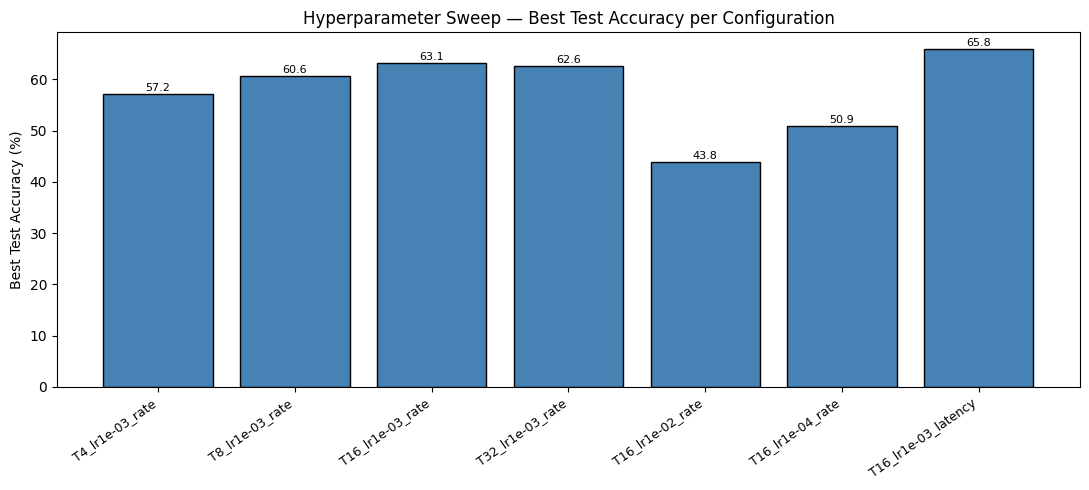


Rank  Config                      Best Test Acc  Final Train Acc
1     T16_lr1e-03_latency                65.85%           71.11%
2     T16_lr1e-03_rate                   63.09%           70.00%
3     T32_lr1e-03_rate                   62.64%           68.79%
4     T8_lr1e-03_rate                    60.63%           64.59%
5     T4_lr1e-03_rate                    57.16%           59.59%
6     T16_lr1e-04_rate                   50.94%           51.36%
7     T16_lr1e-02_rate                   43.82%           44.30%

All plots saved to ./results/


In [9]:
# ── Bar chart: best accuracy per config ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
tags = [r["tag"] for r in results]
accs = [r["best_test_acc"]*100 for r in results]
bars = ax.bar(range(len(tags)), accs, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(tags)))
ax.set_xticklabels(tags, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Best Test Accuracy (%)")
ax.set_title("Hyperparameter Sweep — Best Test Accuracy per Configuration")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{acc:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/sweep_summary.png", dpi=150)
plt.show()

# ── Ranked results table ─────────────────────────────────────────────────────
print("\n" + "="*62)
print(f"{'Rank':<5} {'Config':<26} {'Best Test Acc':>14} {'Final Train Acc':>16}")
print("="*62)
for rank, r in enumerate(
        sorted(results, key=lambda r: -r["best_test_acc"]), 1):
    print(f"{rank:<5} {r['tag']:<26} "
          f"{r['best_test_acc']*100:>13.2f}% "
          f"{r['train_accs'][-1]*100:>15.2f}%")
print("="*62)
print(f"\nAll plots saved to ./{RESULTS_DIR}/")

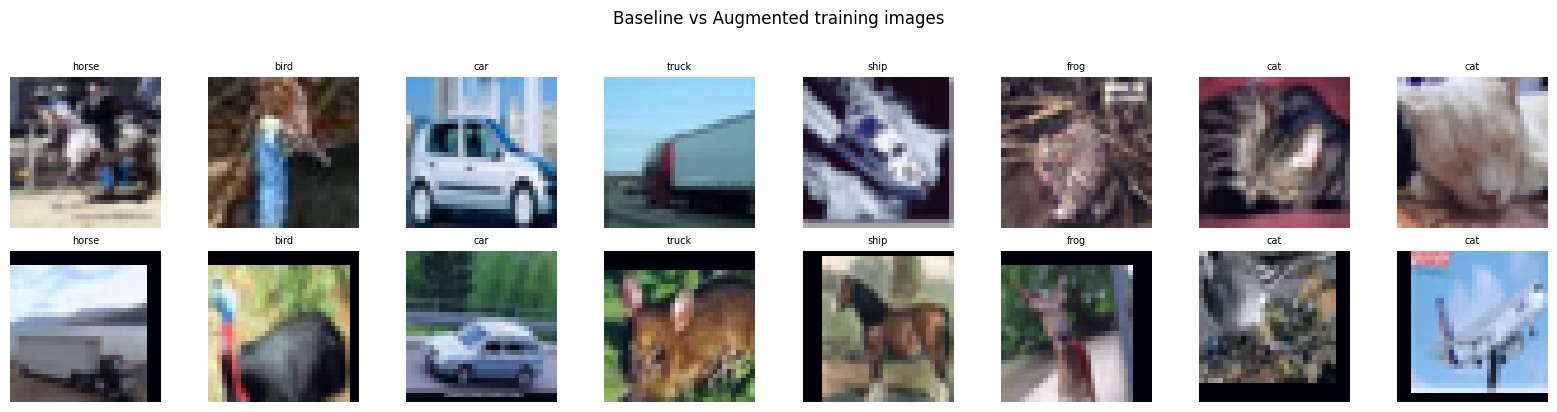

✓ Augmented data loaders ready


In [10]:
# ── Augmented training transform ─────────────────────────────────────────────
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2023, 0.1994, 0.2010),
    ),
])

transform_test_clean = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2023, 0.1994, 0.2010),
    ),
])

aug_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=False, transform=transform_augmented)
aug_test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_test_clean)

aug_train_loader = DataLoader(
    aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
aug_test_loader  = DataLoader(
    aug_test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Visualise augmentation effect
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
base_imgs, base_labels = next(iter(train_loader))
aug_imgs,  _           = next(iter(aug_train_loader))

for i in range(8):
    for row, (imgs, title) in enumerate([
            (base_imgs, 'No augmentation'),
            (aug_imgs,  'Augmented')]):
        img = imgs[i].permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        axes[row, i].imshow(img)
        axes[row, i].axis('off')
        if i == 0:
            axes[row, i].set_ylabel(title, fontsize=9)
        axes[row, i].set_title(CLASSES[base_labels[i]], fontsize=7)

plt.suptitle('Baseline vs Augmented training images', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/augmentation_examples.png', dpi=150)
plt.show()
print('✓ Augmented data loaders ready')

In [11]:
# ── Augmentation experiment ───────────────────────────────────────────────
# Best baseline: T=16, LR=1e-3, latency — 64.59% test acc
T_aug   = 16
LR_aug  = 1e-3
ENC_aug = 'latency'
tag_aug = f'T{T_aug}_lr{LR_aug:.0e}_{ENC_aug}_augmented'

print(f'Running: {tag_aug}')
print(f'Baseline to compare: 64.59% test acc')
print('='*55)

encoder_aug   = ENCODINGS[ENC_aug]
model_aug     = CIFAR_CSNN(beta=0.9).to(DEVICE)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=LR_aug)
scheduler_aug = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_aug, T_max=EPOCHS)

aug_train_losses, aug_train_accs, aug_test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_aug, aug_train_loader, optimizer_aug,
        encoder_aug, T_aug, DEVICE)
    te_acc = evaluate(
        model_aug, aug_test_loader, encoder_aug, T_aug, DEVICE)
    scheduler_aug.step()

    aug_train_losses.append(tr_loss)
    aug_train_accs.append(tr_acc)
    aug_test_accs.append(te_acc)

    print(f'  Epoch {epoch:2d}/{EPOCHS} | '
          f'loss={tr_loss:.4f} | '
          f'train={tr_acc*100:.1f}% | '
          f'test={te_acc*100:.1f}%')

aug_best = max(aug_test_accs)
print(f'\n✓ Augmented best test accuracy: {aug_best*100:.2f}%')
print(f'  Baseline (no augmentation):   64.59%')
print(f'  Delta:                        {(aug_best - 0.6459)*100:+.2f} pp')

Running: T16_lr1e-03_latency_augmented
Baseline to compare: 64.59% test acc
  Epoch  1/20 | loss=1.8946 | train=29.6% | test=40.2%
  Epoch  2/20 | loss=1.5801 | train=42.1% | test=48.3%
  Epoch  3/20 | loss=1.4821 | train=46.6% | test=50.0%
  Epoch  4/20 | loss=1.4152 | train=49.0% | test=53.5%
  Epoch  5/20 | loss=1.3664 | train=51.0% | test=55.4%
  Epoch  6/20 | loss=1.3240 | train=52.7% | test=57.2%
  Epoch  7/20 | loss=1.2869 | train=53.8% | test=58.3%
  Epoch  8/20 | loss=1.2577 | train=55.2% | test=58.8%
  Epoch  9/20 | loss=1.2311 | train=56.2% | test=59.3%
  Epoch 10/20 | loss=1.2149 | train=56.5% | test=60.8%
  Epoch 11/20 | loss=1.1930 | train=57.5% | test=60.7%
  Epoch 12/20 | loss=1.1708 | train=58.3% | test=60.8%
  Epoch 13/20 | loss=1.1575 | train=58.6% | test=61.3%
  Epoch 14/20 | loss=1.1436 | train=59.4% | test=61.9%
  Epoch 15/20 | loss=1.1310 | train=59.6% | test=61.1%
  Epoch 16/20 | loss=1.1213 | train=60.1% | test=61.7%
  Epoch 17/20 | loss=1.1162 | train=60.2% | 

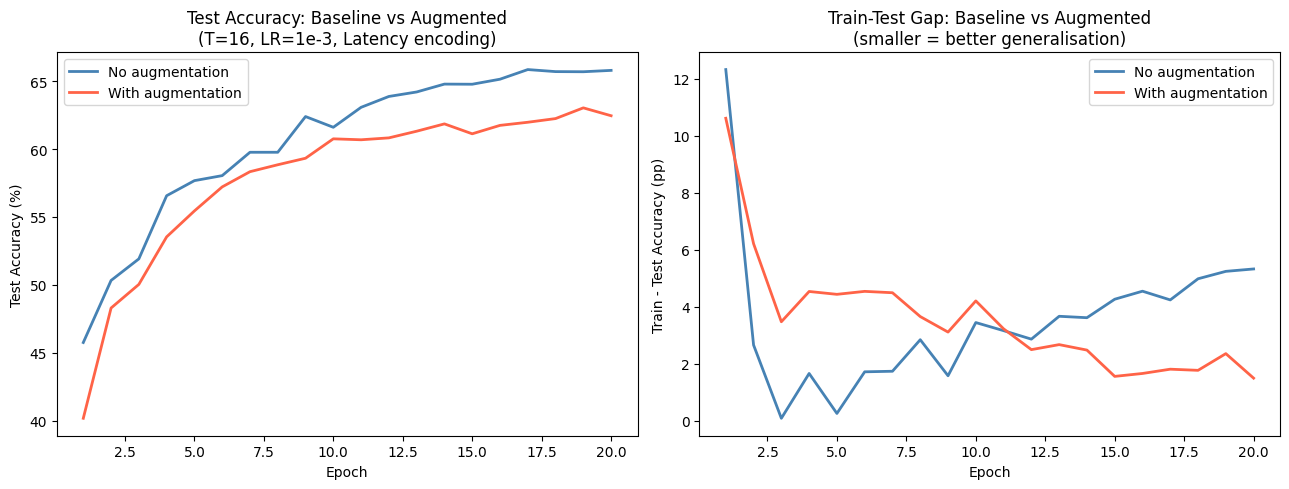


Metric                             Baseline    Augmented
Best test accuracy                   64.59%       63.03%
Final train-test gap                  5.32%        1.49%
Final train accuracy                 71.11%       60.96%

Figures saved to ./results/


In [12]:
# ── Augmentation comparison plots ─────────────────────────────────────────────
baseline = next(r for r in results
                if r['T']==16 and r['lr']==1e-3 and r['encoding']=='latency')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: test accuracy
ax = axes[0]
ax.plot(range(1, EPOCHS+1),
        [a*100 for a in baseline['test_accs']],
        label='No augmentation', color='steelblue', linewidth=2)
ax.plot(range(1, EPOCHS+1),
        [a*100 for a in aug_test_accs],
        label='With augmentation', color='tomato', linewidth=2)
ax.set_title('Test Accuracy: Baseline vs Augmented\n(T=16, LR=1e-3, Latency encoding)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
ax.legend()

# Right: train-test gap
ax = axes[1]
base_gap = [abs(tr - te)*100
            for tr, te in zip(baseline['train_accs'], baseline['test_accs'])]
aug_gap  = [abs(tr - te)*100
            for tr, te in zip(aug_train_accs, aug_test_accs)]
ax.plot(range(1, EPOCHS+1), base_gap,
        label='No augmentation', color='steelblue', linewidth=2)
ax.plot(range(1, EPOCHS+1), aug_gap,
        label='With augmentation', color='tomato', linewidth=2)
ax.set_title('Train-Test Gap: Baseline vs Augmented\n(smaller = better generalisation)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Test Accuracy (pp)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/augmentation_comparison.png', dpi=150)
plt.show()

# Summary table
base_gap_final = abs(baseline['train_accs'][-1] - baseline['test_accs'][-1])*100
aug_gap_final  = abs(aug_train_accs[-1] - aug_test_accs[-1])*100

print('\n' + '='*57)
print(f"{'Metric':<32} {'Baseline':>10} {'Augmented':>12}")
print('='*57)
print(f"{'Best test accuracy':<32} {'64.59%':>10} {aug_best*100:>11.2f}%")
print(f"{'Final train-test gap':<32} {base_gap_final:>9.2f}%  {aug_gap_final:>10.2f}%")
print(f"{'Final train accuracy':<32} {baseline['train_accs'][-1]*100:>9.2f}%  {aug_train_accs[-1]*100:>10.2f}%")
print('='*57)
print(f'\nFigures saved to ./{RESULTS_DIR}/')

In [13]:
# ── Deeper CSNN: 3 conv layers + wider FC ────────────────────────────────────
# Motivation: augmentation experiment showed capacity is the bottleneck,
# not overfitting. Adding a third conv layer (32→64) and widening FC (128→256)
# directly addresses this.

class CIFAR_CSNN_Deep(nn.Module):
    def __init__(self, beta=0.9):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid()

        # 3 conv blocks instead of 2
        self.conv1 = nn.Conv2d(3,  16, kernel_size=3, stride=1, padding=1)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # Pool to 4x4 → 64*4*4 = 1024 features
        self.pool    = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten = nn.Flatten()

        # Wider FC: 1024 → 256 (was 512 → 128)
        self.fc1  = nn.Linear(64 * 4 * 4, 256)
        self.lif4 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc_out = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem_out_sum = torch.zeros(x.size(0), NUM_CLASSES, device=x.device)

        for t in range(x.size(1)):
            frame = x[:, t]

            cur1       = self.conv1(frame)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2       = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3       = self.conv3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)

            pooled = self.pool(spk3)
            flat   = self.flatten(pooled)

            cur4       = self.fc1(flat)
            spk4, mem4 = self.lif4(cur4, mem4)

            mem_out_sum += self.fc_out(spk4)

        return mem_out_sum

# Sanity check
dummy      = torch.bernoulli(torch.rand(4, 16, 3, 32, 32))
model_test = CIFAR_CSNN_Deep()
out        = model_test(dummy)
total_params = sum(p.numel() for p in model_test.parameters())
print(f'Output shape:     {out.shape}   ← should be [4, 10]')
print(f'Total parameters: {total_params:,}  (vs {sum(p.numel() for p in CIFAR_CSNN().parameters()):,} in 2-layer model)')
print('✓ Deep model OK')

Output shape:     torch.Size([4, 10])   ← should be [4, 10]
Total parameters: 288,554  (vs 81,002 in 2-layer model)
✓ Deep model OK


Deep CSNN — T=16, LR=1e-03, latency encoding
Baseline to beat: 65.85%
  Epoch  1/20 | loss=1.8718 | train=30.3% | test=44.9%
  Epoch  2/20 | loss=1.3869 | train=49.7% | test=53.6%
  Epoch  3/20 | loss=1.2425 | train=55.4% | test=56.6%
  Epoch  4/20 | loss=1.1399 | train=59.2% | test=59.7%
  Epoch  5/20 | loss=1.0695 | train=62.1% | test=61.7%
  Epoch  6/20 | loss=1.0110 | train=64.1% | test=61.7%
  Epoch  7/20 | loss=0.9568 | train=66.0% | test=62.7%
  Epoch  8/20 | loss=0.9116 | train=67.7% | test=64.4%
  Epoch  9/20 | loss=0.8714 | train=68.9% | test=65.5%
  Epoch 10/20 | loss=0.8275 | train=70.8% | test=66.5%
  Epoch 11/20 | loss=0.7929 | train=72.0% | test=66.6%
  Epoch 12/20 | loss=0.7612 | train=72.9% | test=67.6%
  Epoch 13/20 | loss=0.7308 | train=74.2% | test=67.7%
  Epoch 14/20 | loss=0.6996 | train=75.2% | test=68.0%
  Epoch 15/20 | loss=0.6750 | train=76.1% | test=68.3%
  Epoch 16/20 | loss=0.6545 | train=77.1% | test=68.3%
  Epoch 17/20 | loss=0.6378 | train=77.7% | test=6

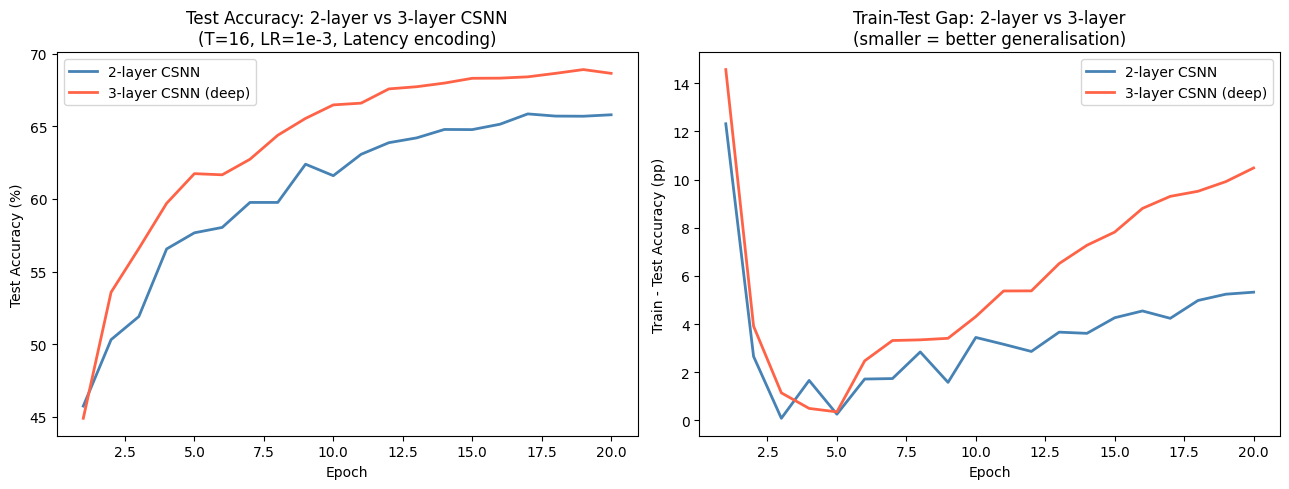


Metric                            2-layer    3-layer
Best test accuracy                 65.85%     68.90%
Final train-test gap                5.32%     10.48%
Parameters                            ~Xk   288,554


In [14]:
# ── Train deep model on best config: T=16, LR=1e-3, latency ──────────────────
T_deep   = 16
LR_deep  = 1e-3
ENC_deep = 'latency'

print(f'Deep CSNN — T={T_deep}, LR={LR_deep:.0e}, {ENC_deep} encoding')
print(f'Baseline to beat: 65.85%')
print('='*55)

encoder_deep   = ENCODINGS[ENC_deep]
model_deep     = CIFAR_CSNN_Deep(beta=0.9).to(DEVICE)
optimizer_deep = optim.Adam(model_deep.parameters(), lr=LR_deep)
scheduler_deep = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_deep, T_max=EPOCHS)

deep_train_losses, deep_train_accs, deep_test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_deep, train_loader, optimizer_deep,
        encoder_deep, T_deep, DEVICE)
    te_acc = evaluate(
        model_deep, test_loader, encoder_deep, T_deep, DEVICE)
    scheduler_deep.step()

    deep_train_losses.append(tr_loss)
    deep_train_accs.append(tr_acc)
    deep_test_accs.append(te_acc)

    print(f'  Epoch {epoch:2d}/{EPOCHS} | '
          f'loss={tr_loss:.4f} | '
          f'train={tr_acc*100:.1f}% | '
          f'test={te_acc*100:.1f}%')

deep_best = max(deep_test_accs)
baseline_best = 0.6585

print(f'\n{"="*45}')
print(f'  Deep model best test acc:  {deep_best*100:.2f}%')
print(f'  Baseline (2-layer):        65.85%')
print(f'  Delta:                     {(deep_best - baseline_best)*100:+.2f} pp')
print(f'{"="*45}')

# ── Comparison plot ───────────────────────────────────────────────────────────
baseline = next(r for r in results
                if r['T']==16 and r['lr']==1e-3 and r['encoding']=='latency')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(range(1, EPOCHS+1),
        [a*100 for a in baseline['test_accs']],
        label='2-layer CSNN', color='steelblue', linewidth=2)
ax.plot(range(1, EPOCHS+1),
        [a*100 for a in deep_test_accs],
        label='3-layer CSNN (deep)', color='tomato', linewidth=2)
ax.set_title('Test Accuracy: 2-layer vs 3-layer CSNN\n(T=16, LR=1e-3, Latency encoding)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
ax.legend()

ax = axes[1]
base_gap = [abs(tr - te)*100
            for tr, te in zip(baseline['train_accs'], baseline['test_accs'])]
deep_gap = [abs(tr - te)*100
            for tr, te in zip(deep_train_accs, deep_test_accs)]
ax.plot(range(1, EPOCHS+1), base_gap,
        label='2-layer CSNN', color='steelblue', linewidth=2)
ax.plot(range(1, EPOCHS+1), deep_gap,
        label='3-layer CSNN (deep)', color='tomato', linewidth=2)
ax.set_title('Train-Test Gap: 2-layer vs 3-layer\n(smaller = better generalisation)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Test Accuracy (pp)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/deep_model_comparison.png', dpi=150)
plt.show()

# Summary
deep_gap_final = abs(deep_train_accs[-1] - deep_test_accs[-1])*100
base_gap_final = abs(baseline['train_accs'][-1] - baseline['test_accs'][-1])*100

print(f'\n{"="*52}')
print(f"{'Metric':<30} {'2-layer':>10} {'3-layer':>10}")
print(f'{"="*52}')
print(f"{'Best test accuracy':<30} {'65.85%':>10} {deep_best*100:>9.2f}%")
print(f"{'Final train-test gap':<30} {base_gap_final:>9.2f}%  {deep_gap_final:>8.2f}%")
print(f"{'Parameters':<30} {'~Xk':>10} {sum(p.numel() for p in model_deep.parameters()):>9,}")
print(f'{"="*52}')

Extended training — 3-layer CSNN, T=16, LR=1e-3, latency
Current best: 68.90% at 20 epochs
  Epoch  1/40 | loss=1.8426 | train=31.9% | test=45.9%
  Epoch  2/40 | loss=1.3933 | train=49.7% | test=53.8%
  Epoch  3/40 | loss=1.2473 | train=55.1% | test=57.3%
  Epoch  4/40 | loss=1.1464 | train=59.1% | test=59.9%
  Epoch  5/40 | loss=1.0796 | train=61.9% | test=61.5%
  Epoch  6/40 | loss=1.0287 | train=63.5% | test=63.6%
  Epoch  7/40 | loss=0.9701 | train=65.6% | test=63.9%
  Epoch  8/40 | loss=0.9199 | train=67.2% | test=65.2%
  Epoch  9/40 | loss=0.8878 | train=68.4% | test=66.1%
  Epoch 10/40 | loss=0.8499 | train=69.9% | test=66.7%
  Epoch 11/40 | loss=0.8060 | train=71.6% | test=68.3%
  Epoch 12/40 | loss=0.7749 | train=72.7% | test=67.3%
  Epoch 13/40 | loss=0.7409 | train=73.8% | test=67.5%
  Epoch 14/40 | loss=0.7130 | train=75.0% | test=68.6%
  Epoch 15/40 | loss=0.6750 | train=76.2% | test=68.0%
  Epoch 16/40 | loss=0.6537 | train=77.0% | test=69.4%
  Epoch 17/40 | loss=0.6203 |

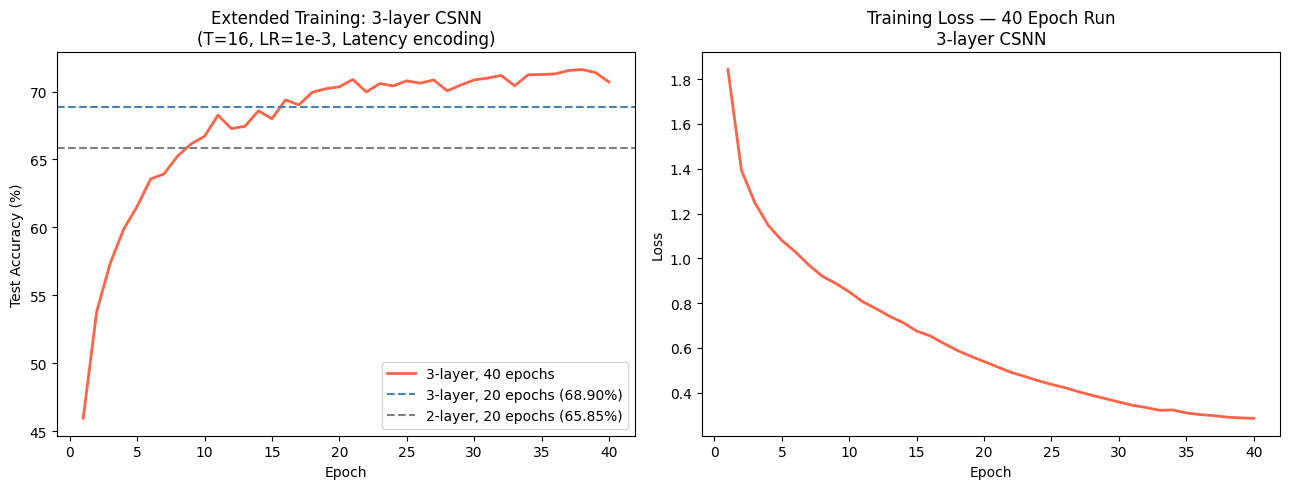


Final train-test gap: 20.76%
Final train accuracy: 91.46%
Final test accuracy:  70.70%


In [15]:
# ── Extended training: 3-layer CSNN for 40 epochs ────────────────────────────
# Motivation: loss curves still descending at epoch 20 for deep model.
# Doubling the budget costs ~5 mins on A100 and may recover 1-3%.

EPOCHS_EXT = 40

print(f'Extended training — 3-layer CSNN, T=16, LR=1e-3, latency')
print(f'Current best: 68.90% at 20 epochs')
print('='*55)

model_ext     = CIFAR_CSNN_Deep(beta=0.9).to(DEVICE)
optimizer_ext = optim.Adam(model_ext.parameters(), lr=1e-3)
scheduler_ext = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ext, T_max=EPOCHS_EXT)

ext_train_losses, ext_train_accs, ext_test_accs = [], [], []

for epoch in range(1, EPOCHS_EXT + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_ext, train_loader, optimizer_ext,
        ENCODINGS['latency'], 16, DEVICE)
    te_acc = evaluate(
        model_ext, test_loader, ENCODINGS['latency'], 16, DEVICE)
    scheduler_ext.step()

    ext_train_losses.append(tr_loss)
    ext_train_accs.append(tr_acc)
    ext_test_accs.append(te_acc)

    print(f'  Epoch {epoch:2d}/{EPOCHS_EXT} | '
          f'loss={tr_loss:.4f} | '
          f'train={tr_acc*100:.1f}% | '
          f'test={te_acc*100:.1f}%')

ext_best = max(ext_test_accs)
print(f'\n{"="*45}')
print(f'  20-epoch best:  68.90%')
print(f'  40-epoch best:  {ext_best*100:.2f}%')
print(f'  Delta:          {(ext_best - 0.6890)*100:+.2f} pp')
print(f'{"="*45}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(range(1, EPOCHS_EXT+1),
        [a*100 for a in ext_test_accs],
        color='tomato', linewidth=2, label='3-layer, 40 epochs')
ax.axhline(y=68.90, color='steelblue', linestyle='--',
           linewidth=1.5, label='3-layer, 20 epochs (68.90%)')
ax.axhline(y=65.85, color='grey', linestyle='--',
           linewidth=1.5, label='2-layer, 20 epochs (65.85%)')
ax.set_title('Extended Training: 3-layer CSNN\n(T=16, LR=1e-3, Latency encoding)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
ax.legend()

ax = axes[1]
ax.plot(range(1, EPOCHS_EXT+1), ext_train_losses,
        color='tomato', linewidth=2)
ax.set_title('Training Loss — 40 Epoch Run\n3-layer CSNN')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/extended_training.png', dpi=150)
plt.show()

# Gap at end
ext_gap_final = abs(ext_train_accs[-1] - ext_test_accs[-1])*100
print(f'\nFinal train-test gap: {ext_gap_final:.2f}%')
print(f'Final train accuracy: {ext_train_accs[-1]*100:.2f}%')
print(f'Final test accuracy:  {ext_test_accs[-1]*100:.2f}%')

In [16]:
# ── 3-layer CSNN + Augmentation + FC Dropout ─────────────────────────────────
# Motivation: 3-layer model hit 71.62% but with 19.6% train-test gap.
# Augmentation alone hurt the 2-layer model (capacity bottleneck).
# Now the 3-layer has enough capacity to absorb augmentation.
# Dropout on FC layer directly targets the overfitting.

class CIFAR_CSNN_Deep_Reg(nn.Module):
    """3-layer CSNN with dropout on the FC layer."""
    def __init__(self, beta=0.9, dropout_p=0.3):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(3,  16, kernel_size=3, stride=1, padding=1)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.pool    = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten = nn.Flatten()

        self.dropout = nn.Dropout(p=dropout_p)   # ← regularisation on FC input
        self.fc1  = nn.Linear(64 * 4 * 4, 256)
        self.lif4 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc_out = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem_out_sum = torch.zeros(x.size(0), NUM_CLASSES, device=x.device)

        for t in range(x.size(1)):
            frame = x[:, t]

            cur1       = self.conv1(frame)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2       = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3       = self.conv3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)

            pooled = self.pool(spk3)
            flat   = self.flatten(pooled)
            flat   = self.dropout(flat)       # ← applied before FC

            cur4       = self.fc1(flat)
            spk4, mem4 = self.lif4(cur4, mem4)

            mem_out_sum += self.fc_out(spk4)

        return mem_out_sum

# ── Train ─────────────────────────────────────────────────────────────────────
print('3-layer CSNN + Augmentation + Dropout (p=0.3)')
print('T=16, LR=1e-3, latency, 40 epochs')
print('Baseline to beat: 71.62%')
print('='*55)

model_reg     = CIFAR_CSNN_Deep_Reg(beta=0.9, dropout_p=0.3).to(DEVICE)
optimizer_reg = optim.Adam(model_reg.parameters(), lr=1e-3)
scheduler_reg = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_reg, T_max=40)

reg_train_losses, reg_train_accs, reg_test_accs = [], [], []

for epoch in range(1, 41):
    tr_loss, tr_acc = train_one_epoch(
        model_reg, aug_train_loader, optimizer_reg,
        ENCODINGS['latency'], 16, DEVICE)
    te_acc = evaluate(
        model_reg, aug_test_loader, ENCODINGS['latency'], 16, DEVICE)
    scheduler_reg.step()

    reg_train_losses.append(tr_loss)
    reg_train_accs.append(tr_acc)
    reg_test_accs.append(te_acc)

    print(f'  Epoch {epoch:2d}/40 | '
          f'loss={tr_loss:.4f} | '
          f'train={tr_acc*100:.1f}% | '
          f'test={te_acc*100:.1f}%')

reg_best = max(reg_test_accs)
reg_gap  = abs(reg_train_accs[reg_test_accs.index(reg_best)] -
               reg_best) * 100
print(f'\n✓ Best test accuracy: {reg_best*100:.2f}%')
print(f'  Gap at best epoch:  {reg_gap:.2f}%')
print(f'  Baseline (no reg):  71.62%')
print(f'  Delta:              {(reg_best - 0.7162)*100:+.2f} pp')

3-layer CSNN + Augmentation + Dropout (p=0.3)
T=16, LR=1e-3, latency, 40 epochs
Baseline to beat: 71.62%
  Epoch  1/40 | loss=2.0279 | train=24.6% | test=42.4%
  Epoch  2/40 | loss=1.5750 | train=42.8% | test=50.0%
  Epoch  3/40 | loss=1.4424 | train=47.9% | test=53.6%
  Epoch  4/40 | loss=1.3498 | train=51.6% | test=56.4%
  Epoch  5/40 | loss=1.2826 | train=53.9% | test=58.3%
  Epoch  6/40 | loss=1.2409 | train=55.4% | test=60.4%
  Epoch  7/40 | loss=1.1962 | train=57.1% | test=60.7%
  Epoch  8/40 | loss=1.1652 | train=58.3% | test=61.5%
  Epoch  9/40 | loss=1.1366 | train=59.4% | test=62.9%
  Epoch 10/40 | loss=1.1103 | train=60.3% | test=62.9%
  Epoch 11/40 | loss=1.0868 | train=61.1% | test=65.0%
  Epoch 12/40 | loss=1.0672 | train=61.9% | test=65.7%
  Epoch 13/40 | loss=1.0334 | train=63.2% | test=66.1%
  Epoch 14/40 | loss=1.0205 | train=63.6% | test=64.6%
  Epoch 15/40 | loss=1.0041 | train=64.1% | test=66.8%
  Epoch 16/40 | loss=0.9864 | train=64.8% | test=67.3%
  Epoch 17/40 |

In [17]:
# ── 3-layer CSNN + Batch Normalisation ───────────────────────────────────────
# Motivation: BatchNorm before LIF stabilises the input current distribution,
# keeping activations near the threshold where surrogate gradient is strongest.
# This should improve convergence speed and reduce the train-test gap.
# Note: BatchNorm is applied BEFORE LIF (on conv output), not after spike.

class CIFAR_CSNN_Deep_BN(nn.Module):
    """3-layer CSNN with BatchNorm before each LIF layer."""
    def __init__(self, beta=0.9):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(3,  16, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(16)    # ← normalise before LIF
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.pool    = nn.AdaptiveAvgPool2d((4, 4))
        self.flatten = nn.Flatten()

        self.fc1  = nn.Linear(64 * 4 * 4, 256)
        self.bn4  = nn.BatchNorm1d(256)    # ← normalise FC output before LIF
        self.lif4 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc_out = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem_out_sum = torch.zeros(x.size(0), NUM_CLASSES, device=x.device)

        for t in range(x.size(1)):
            frame = x[:, t]

            cur1       = self.bn1(self.conv1(frame))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2       = self.bn2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3       = self.bn3(self.conv3(spk2))
            spk3, mem3 = self.lif3(cur3, mem3)

            pooled = self.pool(spk3)
            flat   = self.flatten(pooled)

            cur4       = self.bn4(self.fc1(flat))
            spk4, mem4 = self.lif4(cur4, mem4)

            mem_out_sum += self.fc_out(spk4)

        return mem_out_sum

# ── Train ─────────────────────────────────────────────────────────────────────
print('3-layer CSNN + BatchNorm')
print('T=16, LR=1e-3, latency, 40 epochs')
print('Baseline to beat: 71.62%')
print('='*55)

model_bn     = CIFAR_CSNN_Deep_BN(beta=0.9).to(DEVICE)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=1e-3)
scheduler_bn = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_bn, T_max=40)

bn_train_losses, bn_train_accs, bn_test_accs = [], [], []

for epoch in range(1, 41):
    tr_loss, tr_acc = train_one_epoch(
        model_bn, train_loader, optimizer_bn,
        ENCODINGS['latency'], 16, DEVICE)
    te_acc = evaluate(
        model_bn, test_loader, ENCODINGS['latency'], 16, DEVICE)
    scheduler_bn.step()

    bn_train_losses.append(tr_loss)
    bn_train_accs.append(tr_acc)
    bn_test_accs.append(te_acc)

    print(f'  Epoch {epoch:2d}/40 | '
          f'loss={tr_loss:.4f} | '
          f'train={tr_acc*100:.1f}% | '
          f'test={te_acc*100:.1f}%')

bn_best = max(bn_test_accs)
bn_gap  = abs(bn_train_accs[bn_test_accs.index(bn_best)] -
              bn_best) * 100
print(f'\n✓ Best test accuracy: {bn_best*100:.2f}%')
print(f'  Gap at best epoch:  {bn_gap:.2f}%')
print(f'  Baseline (no BN):   71.62%')
print(f'  Delta:              {(bn_best - 0.7162)*100:+.2f} pp')

3-layer CSNN + BatchNorm
T=16, LR=1e-3, latency, 40 epochs
Baseline to beat: 71.62%
  Epoch  1/40 | loss=1.4894 | train=49.1% | test=33.4%
  Epoch  2/40 | loss=1.1241 | train=60.2% | test=44.1%
  Epoch  3/40 | loss=0.9960 | train=64.9% | test=47.5%
  Epoch  4/40 | loss=0.9035 | train=68.2% | test=53.4%
  Epoch  5/40 | loss=0.8216 | train=70.9% | test=56.5%
  Epoch  6/40 | loss=0.7583 | train=73.2% | test=55.8%
  Epoch  7/40 | loss=0.7035 | train=75.2% | test=60.8%
  Epoch  8/40 | loss=0.6539 | train=77.2% | test=64.1%
  Epoch  9/40 | loss=0.5994 | train=78.7% | test=61.5%
  Epoch 10/40 | loss=0.5588 | train=80.2% | test=64.0%
  Epoch 11/40 | loss=0.5243 | train=81.5% | test=63.2%
  Epoch 12/40 | loss=0.4795 | train=83.0% | test=65.6%
  Epoch 13/40 | loss=0.4436 | train=84.2% | test=59.5%
  Epoch 14/40 | loss=0.4046 | train=85.6% | test=63.0%
  Epoch 15/40 | loss=0.3692 | train=87.0% | test=58.7%
  Epoch 16/40 | loss=0.3425 | train=88.0% | test=59.0%
  Epoch 17/40 | loss=0.3073 | train=

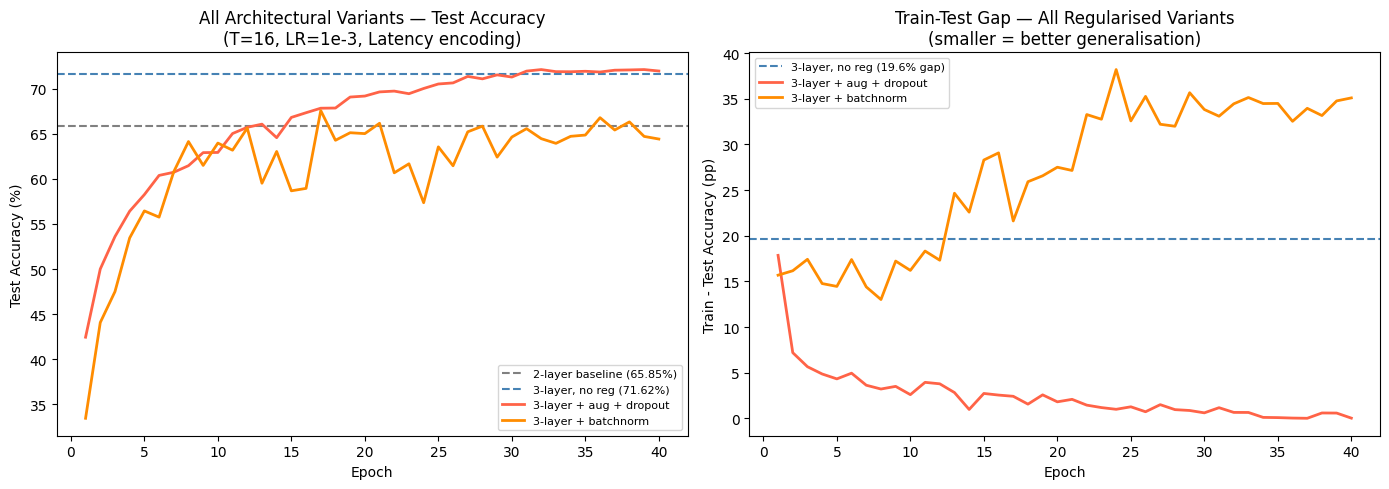


Model                                     Best Test        Gap
  2-layer, no aug, 20ep                      65.85%      5.32%
  2-layer, augmented, 20ep                   63.00%      1.80%
  3-layer, no reg, 20ep                      68.90%     10.48%
  3-layer, no reg, 40ep                      71.62%     19.60%
  3-layer + aug + dropout, 40ep              72.14%      0.03%
  3-layer + batchnorm, 40ep                  67.59%     35.09%

All figures saved to ./results/


In [18]:
# ── Final comparison: all architectural variants ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
# Reference lines
ax.axhline(y=65.85, color='grey',      linestyle='--', linewidth=1.5,
           label='2-layer baseline (65.85%)')
ax.axhline(y=71.62, color='steelblue', linestyle='--', linewidth=1.5,
           label='3-layer, no reg (71.62%)')
# New experiments
ax.plot(range(1, 41), [a*100 for a in reg_test_accs],
        color='tomato',      linewidth=2, label='3-layer + aug + dropout')
ax.plot(range(1, 41), [a*100 for a in bn_test_accs],
        color='darkorange',  linewidth=2, label='3-layer + batchnorm')
ax.set_title('All Architectural Variants — Test Accuracy\n(T=16, LR=1e-3, Latency encoding)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
ax.legend(fontsize=8)

ax = axes[1]
ax.axhline(y=19.6, color='steelblue', linestyle='--', linewidth=1.5,
           label='3-layer, no reg (19.6% gap)')
reg_gap_curve = [abs(tr - te)*100
                 for tr, te in zip(reg_train_accs, reg_test_accs)]
bn_gap_curve  = [abs(tr - te)*100
                 for tr, te in zip(bn_train_accs,  bn_test_accs)]
ax.plot(range(1, 41), reg_gap_curve,
        color='tomato',     linewidth=2, label='3-layer + aug + dropout')
ax.plot(range(1, 41), bn_gap_curve,
        color='darkorange', linewidth=2, label='3-layer + batchnorm')
ax.set_title('Train-Test Gap — All Regularised Variants\n(smaller = better generalisation)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train - Test Accuracy (pp)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/regularisation_comparison.png', dpi=150)
plt.show()

# ── Final summary table ───────────────────────────────────────────────────────
print('\n' + '='*65)
print(f"{'Model':<40} {'Best Test':>10} {'Gap':>10}")
print('='*65)
rows = [
    ('2-layer, no aug, 20ep',           65.85, 5.32),
    ('2-layer, augmented, 20ep',        63.00, 1.80),
    ('3-layer, no reg, 20ep',           68.90, 10.48),
    ('3-layer, no reg, 40ep',           71.62, 19.60),
    ('3-layer + aug + dropout, 40ep',   reg_best*100, abs(reg_train_accs[-1]-reg_test_accs[-1])*100),
    ('3-layer + batchnorm, 40ep',       bn_best*100,  abs(bn_train_accs[-1]-bn_test_accs[-1])*100),
]
for name, acc, gap in rows:
    print(f'  {name:<38} {acc:>9.2f}%  {gap:>8.2f}%')
print('='*65)
print(f'\nAll figures saved to ./{RESULTS_DIR}/')

In [19]:
# Save best model weights
import os
os.makedirs('saved_models', exist_ok=True)

# Save the aug + dropout model (best result: 72.14%)
torch.save(model_reg.state_dict(),
           'saved_models/csnn_3layer_aug_dropout_72.14.pth')

# Download
from google.colab import files
files.download('saved_models/csnn_3layer_aug_dropout_72.14.pth')

print('✓ Model saved and downloading')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Model saved and downloading
